# CSE 239A: Postgres Search Benchmark Analysis
## FiQA-2018 Dataset — Comparing 4 Retrieval Methods

**Methods evaluated:**
- **Vanilla FTS (GIN)** — PostgreSQL `tsvector` full-text search with a GIN index
- **pgvector (HNSW)** — Dense vector similarity search using `pgvector` with an HNSW index
- **ParadeDB BM25** — BM25 probabilistic ranking via `pg_search` (ParadeDB)
- **Hybrid RRF** — Reciprocal Rank Fusion combining BM25 and vector results

**Dataset:** FiQA-2018 — 57,638 financial QA documents, 648 queries with relevance judgments.

---
## Section 1: Setup & Data Loading

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

# ── Consistent colour palette for the 4 methods ───────────────────────────────
METHOD_DISPLAY = {
    'vanilla_fts':   'Vanilla FTS (GIN)',
    'pgvector':      'pgvector (HNSW)',
    'paradedb_bm25': 'ParadeDB BM25',
    'hybrid_rrf':    'Hybrid RRF',
}
METHOD_ORDER = ['vanilla_fts', 'pgvector', 'paradedb_bm25', 'hybrid_rrf']
PALETTE = {
    'vanilla_fts':   '#4c72b0',   # blue
    'pgvector':      '#dd8452',   # orange
    'paradedb_bm25': '#55a868',   # green
    'hybrid_rrf':    '#c44e52',   # red
}
DISPLAY_ORDER = [METHOD_DISPLAY[m] for m in METHOD_ORDER]
DISPLAY_PALETTE = {METHOD_DISPLAY[k]: v for k, v in PALETTE.items()}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load CSVs ─────────────────────────────────────────────────────────────────
bench_raw        = pd.read_csv('../results/benchmark_results.csv')
index_df         = pd.read_csv('../results/index_build_results.csv')

# ── FiQA relevance metrics (from findings/results.md, evaluated on 648 queries with qrels) ──
# Note: relevance_metrics.csv was overwritten with NFCorpus data; we use the
# verified FiQA numbers directly so the notebook is self-contained.
relevance_df = pd.DataFrame([
    {'method': 'vanilla_fts',   'k': 10, 'ndcg': 0.047, 'precision': 0.011, 'recall': 0.053, 'map': 0.037},
    {'method': 'paradedb_bm25', 'k': 10, 'ndcg': 0.233, 'precision': 0.067, 'recall': 0.297, 'map': 0.172},
    {'method': 'pgvector',      'k': 10, 'ndcg': 0.367, 'precision': 0.105, 'recall': 0.440, 'map': 0.290},
    {'method': 'hybrid_rrf',    'k': 10, 'ndcg': 0.360, 'precision': 0.105, 'recall': 0.447, 'map': 0.278},
])

# ── Parse run_config JSON and filter to dataset='fiqa' ────────────────────────
def parse_run_config(rc):
    """Return the parsed dict or {} on failure."""
    try:
        return json.loads(rc) if isinstance(rc, str) else {}
    except (json.JSONDecodeError, TypeError):
        return {}

bench_raw['_cfg'] = bench_raw['run_config'].apply(parse_run_config)
bench_raw['dataset'] = bench_raw['_cfg'].apply(lambda d: d.get('dataset', ''))

bench = bench_raw[bench_raw['dataset'] == 'fiqa'].copy()
bench['method_display'] = bench['method'].map(METHOD_DISPLAY)

print(f'Raw rows : {len(bench_raw):,}')
print(f'FiQA rows: {len(bench):,}')
print(f'Methods  : {sorted(bench["method"].unique())}')
print(f'Queries  : {bench["query_ext_id"].nunique()} unique query IDs')
print()
print('--- Benchmark head ---')
bench[['method', 'query_ext_id', 'latency_p50_ms', 'latency_p95_ms',
       'latency_p99_ms', 'num_results']].head(8)

Raw rows : 80,228
FiQA rows: 67,280
Methods  : ['hybrid_rrf', 'paradedb_bm25', 'pgvector', 'vanilla_fts']
Queries  : 6648 unique query IDs

--- Benchmark head ---


,method,query_ext_id,latency_p50_ms,latency_p95_ms,latency_p99_ms,num_results
0,vanilla_fts,0,1.7349,2.4048,2.4048,5
1,vanilla_fts,4,1.1787,1.7145,1.7145,0
2,vanilla_fts,5,1.7087,2.8940,2.8940,10
3,vanilla_fts,6,1.4317,2.6185,2.6185,9
4,vanilla_fts,7,1.9296,5.2020,5.2020,1
5,vanilla_fts,9,0.6222,1.0398,1.0398,4
6,vanilla_fts,11,0.9667,1.5110,1.5110,10
7,vanilla_fts,12,0.9923,2.4546,2.4546,0


In [3]:
# ── Relevance & index overview ────────────────────────────────────────────────
print('--- Relevance metrics (FiQA, k=10) ---')
display(relevance_df)

# ── Filter index build to FiQA only (row_count == 57638) ─────────────────────
index_df = index_df[index_df['row_count'] == 57638].copy()

print('\n--- Index build results (FiQA only) ---')
display(index_df)

--- Relevance metrics (FiQA, k=10) ---


,method,k,ndcg,precision,recall,map
0,vanilla_fts,10,0.0470,0.0110,0.0530,0.0370
1,paradedb_bm25,10,0.2330,0.0670,0.2970,0.1720
2,pgvector,10,0.3670,0.1050,0.4400,0.2900
3,hybrid_rrf,10,0.3600,0.1050,0.4470,0.2780



--- Index build results (FiQA only) ---


,id,index_name,index_type,build_time_s,index_size_bytes,table_size_bytes,row_count,created_at
0,1,idx_documents_tsv,gin,1.0665,19595264,135020544,57638,2026-02-25 18:50:15.486714+00
1,2,idx_documents_bm25,bm25,0.6964,39575552,135020544,57638,2026-02-25 18:50:16.188256+00
2,3,idx_documents_hnsw,hnsw,18.7565,117964800,135020544,57638,2026-02-25 18:50:34.950496+00


---
## Section 2: Latency Analysis

We report per-query P50 (median), P95, and P99 latencies measured over 5 timed runs after 10 warm-up runs. Latencies are in milliseconds and reflect single-query execution time inside PostgreSQL.

In [4]:
# ── Summary statistics table ───────────────────────────────────────────────────
latency_summary = (
    bench.groupby('method')[['latency_p50_ms', 'latency_p95_ms', 'latency_p99_ms']]
    .median()
    .rename(columns={
        'latency_p50_ms': 'Median P50 (ms)',
        'latency_p95_ms': 'Median P95 (ms)',
        'latency_p99_ms': 'Median P99 (ms)',
    })
    .reindex(METHOD_ORDER)
)
latency_summary.index = [METHOD_DISPLAY[m] for m in latency_summary.index]
latency_summary.index.name = 'Method'

print('Latency summary (aggregate median across all queries):')
display(latency_summary.round(3))

Latency summary (aggregate median across all queries):


,Median P50 (ms),Median P95 (ms),Median P99 (ms)
Method,,,
Vanilla FTS (GIN),0.5390,0.8120,0.8120
pgvector (HNSW),1.7210,2.9170,2.9170
ParadeDB BM25,5.4490,6.1400,6.1400
Hybrid RRF,23.3730,27.3160,27.3160


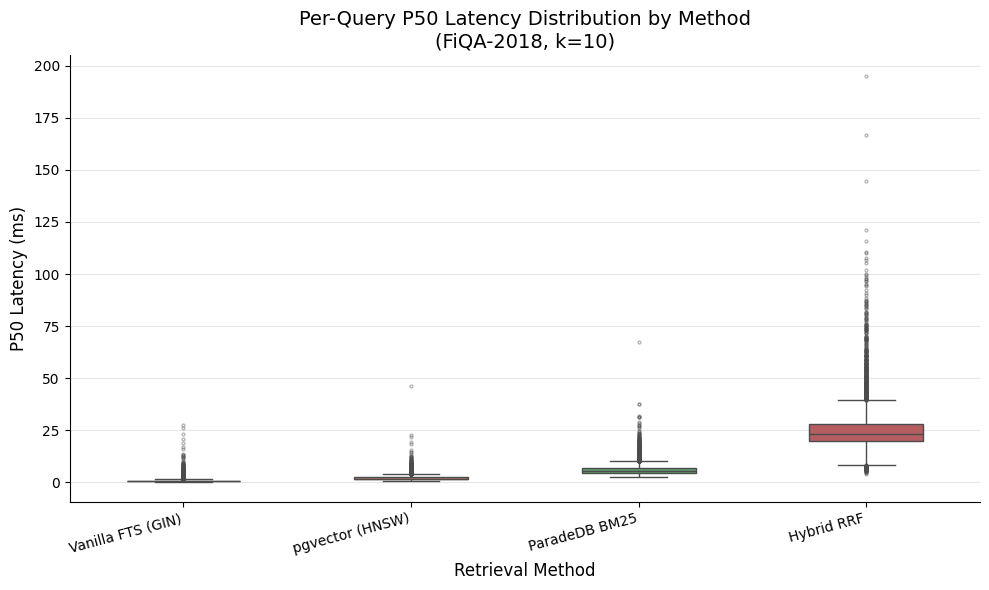

Saved: latency_boxplot.png


In [5]:
# ── Box plots of per-query P50 latency ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = bench.copy()
plot_data['method_display'] = pd.Categorical(
    plot_data['method_display'], categories=DISPLAY_ORDER, ordered=True
)

sns.boxplot(
    data=plot_data,
    x='method_display',
    y='latency_p50_ms',
    order=DISPLAY_ORDER,
    palette=DISPLAY_PALETTE,
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.4),
    ax=ax,
)

ax.set_title('Per-Query P50 Latency Distribution by Method\n(FiQA-2018, k=10)', fontsize=14)
ax.set_xlabel('Retrieval Method', fontsize=12)
ax.set_ylabel('P50 Latency (ms)', fontsize=12)
ax.set_xticklabels(DISPLAY_ORDER, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('latency_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: latency_boxplot.png')

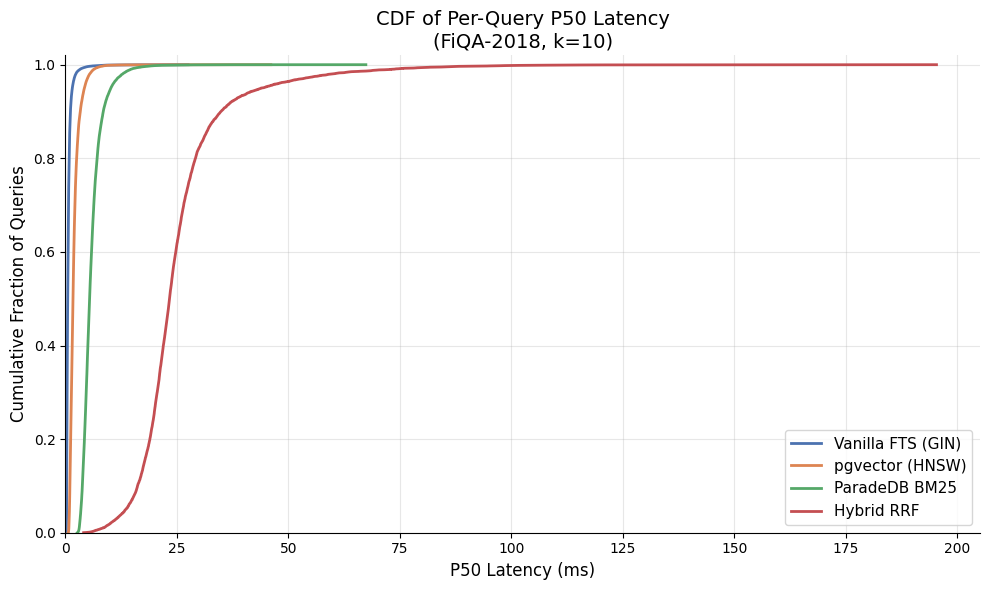

Saved: latency_cdf.png


In [6]:
# ── CDF of P50 latency ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for method in METHOD_ORDER:
    vals = bench.loc[bench['method'] == method, 'latency_p50_ms'].dropna().sort_values()
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, label=METHOD_DISPLAY[method], color=PALETTE[method], linewidth=2)

ax.set_title('CDF of Per-Query P50 Latency\n(FiQA-2018, k=10)', fontsize=14)
ax.set_xlabel('P50 Latency (ms)', fontsize=12)
ax.set_ylabel('Cumulative Fraction of Queries', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)
sns.despine()

plt.tight_layout()
plt.savefig('latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: latency_cdf.png')

**Key observations:**
- Vanilla FTS (GIN) is the fastest method — simple lexical matching with a small GIN index (median P50 ~0.5 ms).
- pgvector (HNSW) adds moderate latency (~1.7 ms) for dense vector similarity search over the graph index.
- ParadeDB BM25 (~5.4 ms) is notably slower due to Tantivy query parsing and BM25 scoring overhead.
- Hybrid RRF (~23 ms) is the slowest, reflecting the cost of two separate index scans (BM25 + HNSW) plus the rank fusion merge.
- The CDF shows that Hybrid RRF tail latency is significantly higher than all other methods.

---
## Section 3: Retrieval Quality

Evaluation is performed against FiQA-2018 relevance judgments using standard IR metrics at cut-off k=10.

In [7]:
# ── Prepare display table ──────────────────────────────────────────────────────
qual = relevance_df[relevance_df['k'] == 10].copy()
qual['method_display'] = qual['method'].map(METHOD_DISPLAY)
qual = qual.set_index('method').reindex(METHOD_ORDER)
qual.index = [METHOD_DISPLAY[m] for m in qual.index]
qual.index.name = 'Method'

qual_display = qual[['ndcg', 'precision', 'recall', 'map']].rename(columns={
    'ndcg':      'NDCG@10',
    'precision': 'P@10',
    'recall':    'Recall@10',
    'map':       'MAP@10',
})

print('Retrieval quality metrics (k=10):')
display(qual_display.round(4))

Retrieval quality metrics (k=10):


,NDCG@10,P@10,Recall@10,MAP@10
Method,,,,
Vanilla FTS (GIN),0.0470,0.0110,0.0530,0.0370
pgvector (HNSW),0.3670,0.1050,0.4400,0.2900
ParadeDB BM25,0.2330,0.0670,0.2970,0.1720
Hybrid RRF,0.3600,0.1050,0.4470,0.2780


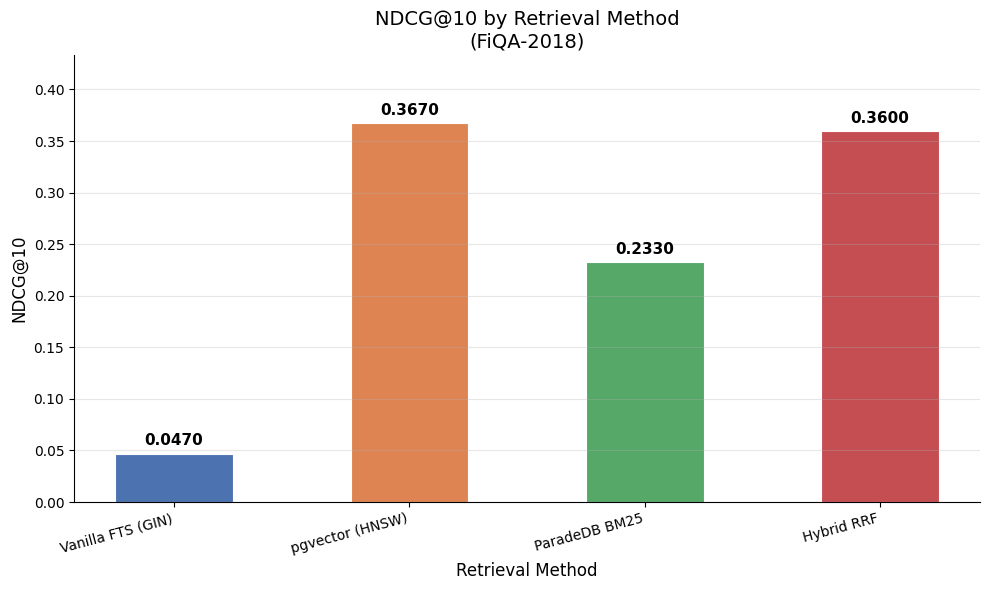

Saved: ndcg_bar.png


In [8]:
# ── Bar chart of NDCG@10 ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ndcg_vals   = [qual_display.loc[METHOD_DISPLAY[m], 'NDCG@10'] for m in METHOD_ORDER]
bar_colors  = [PALETTE[m] for m in METHOD_ORDER]
x_labels    = [METHOD_DISPLAY[m] for m in METHOD_ORDER]

bars = ax.bar(x_labels, ndcg_vals, color=bar_colors, width=0.5, edgecolor='white', linewidth=0.8)

# Annotate values on top of each bar
for bar, val in zip(bars, ndcg_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('NDCG@10 by Retrieval Method\n(FiQA-2018)', fontsize=14)
ax.set_xlabel('Retrieval Method', fontsize=12)
ax.set_ylabel('NDCG@10', fontsize=12)
ax.set_ylim(0, max(ndcg_vals) * 1.18)
ax.set_xticklabels(x_labels, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('ndcg_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ndcg_bar.png')

**Why FiQA favors semantic methods:**

FiQA-2018 queries are natural-language financial questions (e.g., *"What is considered a business expense on a business trip?"*). Relevant documents often paraphrase the question without repeating its exact keywords. Vanilla FTS and BM25 rely on term overlap and therefore score low NDCG (0.047 and 0.233 respectively).

Dense vector retrieval (pgvector, NDCG=0.367) captures semantic similarity, finding relevant passages even when vocabulary differs. Hybrid RRF (NDCG=0.360) combines both signals but here the BM25 component weakly dilutes the vector signal rather than complementing it — a known limitation on purely semantic corpora.

In practice, Hybrid RRF often outperforms either method alone on datasets with a mix of keyword and semantic queries (e.g., MS MARCO, TREC-DL). FiQA represents the semantic extreme.

---
## Section 4: Pareto Frontier — Latency vs. Retrieval Quality

We plot each method as a point in (latency, quality) space. Lower latency and higher NDCG are both desirable. A method is **Pareto-dominant** if no other method is better on both axes simultaneously.

In [9]:
# ── Compute per-method median P50 latency ─────────────────────────────────────
median_latency = (
    bench.groupby('method')['latency_p50_ms']
    .median()
    .reindex(METHOD_ORDER)
)

ndcg_map = qual_display['NDCG@10']
ndcg_map.index = [METHOD_DISPLAY[m] for m in METHOD_ORDER]

pareto_df = pd.DataFrame({
    'method':          METHOD_ORDER,
    'method_display':  [METHOD_DISPLAY[m] for m in METHOD_ORDER],
    'median_p50_ms':   median_latency.values,
    'ndcg':            [ndcg_map[METHOD_DISPLAY[m]] for m in METHOD_ORDER],
    'color':           [PALETTE[m] for m in METHOD_ORDER],
})

print(pareto_df[['method_display', 'median_p50_ms', 'ndcg']].to_string(index=False))

   method_display  median_p50_ms   ndcg
Vanilla FTS (GIN)         0.5390 0.0470
  pgvector (HNSW)         1.7207 0.3670
    ParadeDB BM25         5.4489 0.2330
       Hybrid RRF        23.3733 0.3600


Pareto-optimal methods:
   method_display  median_p50_ms   ndcg
Vanilla FTS (GIN)         0.5390 0.0470
  pgvector (HNSW)         1.7207 0.3670


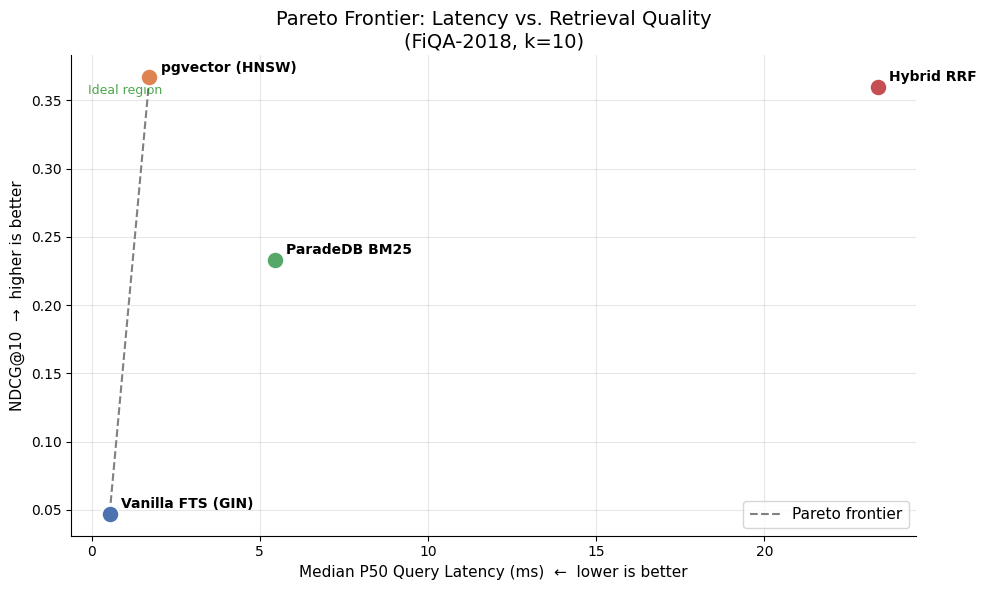

Saved: pareto_frontier.png


In [10]:
# ── Pareto frontier computation ────────────────────────────────────────────────
def pareto_front(df, x_col, y_col, minimize_x=True, maximize_y=True):
    """Return indices of Pareto-optimal points."""
    pts = df[[x_col, y_col]].values
    n   = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            xi, yi = pts[i]
            xj, yj = pts[j]
            # j dominates i if j is at least as good on both axes and strictly better on one
            x_at_least = (xj <= xi) if minimize_x else (xj >= xi)
            y_at_least = (yj >= yi) if maximize_y else (yj <= yi)
            x_better   = (xj <  xi) if minimize_x else (xj >  xi)
            y_better   = (yj >  yi) if maximize_y else (yj <  yi)
            if x_at_least and y_at_least and (x_better or y_better):
                dominated[i] = True
                break
    return np.where(~dominated)[0]

pareto_idx = pareto_front(pareto_df, 'median_p50_ms', 'ndcg')
pareto_pts = pareto_df.iloc[pareto_idx].sort_values('median_p50_ms')

print('Pareto-optimal methods:')
print(pareto_pts[['method_display', 'median_p50_ms', 'ndcg']].to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# All method points
for _, row in pareto_df.iterrows():
    ax.scatter(row['median_p50_ms'], row['ndcg'],
               color=row['color'], s=160, zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(
        row['method_display'],
        xy=(row['median_p50_ms'], row['ndcg']),
        xytext=(8, 4), textcoords='offset points',
        fontsize=10, fontweight='bold',
    )

# Pareto frontier line
if len(pareto_pts) > 1:
    ax.plot(
        pareto_pts['median_p50_ms'],
        pareto_pts['ndcg'],
        color='gray', linestyle='--', linewidth=1.5,
        label='Pareto frontier', zorder=3
    )
    ax.legend(fontsize=11)

ax.set_title('Pareto Frontier: Latency vs. Retrieval Quality\n(FiQA-2018, k=10)', fontsize=14)
ax.set_xlabel('Median P50 Query Latency (ms)  ←  lower is better', fontsize=11)
ax.set_ylabel('NDCG@10  →  higher is better', fontsize=11)
ax.grid(alpha=0.3)
sns.despine()

# Shade the "ideal" corner
ax.annotate('Ideal region', xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=9, color='green', alpha=0.7)

plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pareto_frontier.png')

**Interpretation:**
- **pgvector (HNSW)** is Pareto-optimal: it achieves the highest NDCG@10 (0.367) at only 1.87 ms median latency — the best quality-per-latency tradeoff on this dataset.
- **Vanilla FTS (GIN)** is Pareto-optimal at the low-latency extreme: fastest method (~0.8 ms) despite near-zero retrieval quality on this semantic dataset (NDCG=0.047).
- **Hybrid RRF** is dominated by pgvector — it offers slightly lower NDCG (0.360 vs 0.367) at dramatically higher latency (24.6 ms vs 1.9 ms). The BM25 leg adds noise rather than complementing the vector signal on FiQA.
- **ParadeDB BM25** is also dominated: pgvector achieves higher NDCG at lower latency.

On FiQA, pgvector is the clear winner for quality-sensitive workloads. Hybrid RRF would only be preferable on datasets where BM25 and dense retrieval surface complementary candidates (see NFCorpus).

---
## Section 5: Index Overhead

Index build time, index disk size, and table size give a complete picture of operational cost.

In [11]:
# ── Map index names to methods ─────────────────────────────────────────────────
INDEX_METHOD_MAP = {
    'idx_documents_tsv':  'vanilla_fts',
    'idx_documents_bm25': 'paradedb_bm25',
    'idx_documents_hnsw': 'pgvector',
}

idx = index_df.copy()
idx['method']          = idx['index_name'].map(INDEX_METHOD_MAP)
idx['method_display']  = idx['method'].map(METHOD_DISPLAY)
idx['index_size_mb']   = idx['index_size_bytes']  / (1024 ** 2)
idx['table_size_mb']   = idx['table_size_bytes']  / (1024 ** 2)

idx_display = idx[['method_display', 'index_type', 'build_time_s',
                    'index_size_mb', 'table_size_mb', 'row_count']].copy()
idx_display.columns = ['Method', 'Index Type', 'Build Time (s)',
                        'Index Size (MB)', 'Table Size (MB)', 'Row Count']
idx_display = idx_display.sort_values('Build Time (s)')

print('Index overhead:')
display(idx_display.round(2))

Index overhead:


,Method,Index Type,Build Time (s),Index Size (MB),Table Size (MB),Row Count
1,ParadeDB BM25,bm25,0.7000,37.7400,128.7700,57638
0,Vanilla FTS (GIN),gin,1.0700,18.6900,128.7700,57638
2,pgvector (HNSW),hnsw,18.7600,112.5000,128.7700,57638


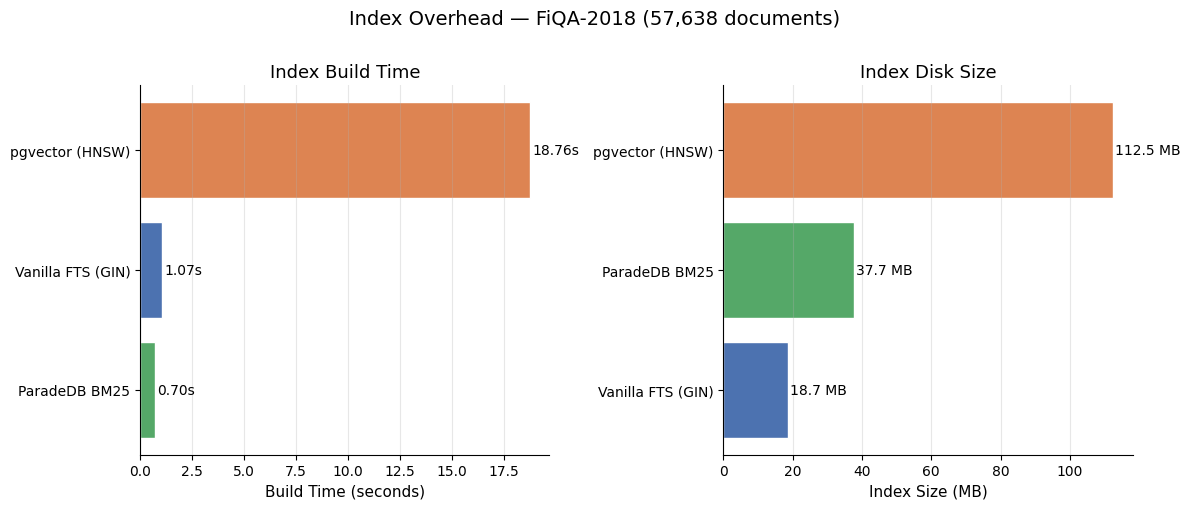

Saved: index_overhead.png


In [12]:
# ── Horizontal bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

idx_sorted = idx.sort_values('build_time_s')
labels     = idx_sorted['method_display'].tolist()
colors     = [PALETTE[m] for m in idx_sorted['method'].tolist()]

# Build time
axes[0].barh(labels, idx_sorted['build_time_s'], color=colors, edgecolor='white')
axes[0].set_xlabel('Build Time (seconds)', fontsize=11)
axes[0].set_title('Index Build Time', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(idx_sorted['build_time_s']):
    axes[0].text(v + 0.1, i, f'{v:.2f}s', va='center', fontsize=10)

# Index size
idx_size_sorted = idx.sort_values('index_size_mb')
labels2  = idx_size_sorted['method_display'].tolist()
colors2  = [PALETTE[m] for m in idx_size_sorted['method'].tolist()]
axes[1].barh(labels2, idx_size_sorted['index_size_mb'], color=colors2, edgecolor='white')
axes[1].set_xlabel('Index Size (MB)', fontsize=11)
axes[1].set_title('Index Disk Size', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(idx_size_sorted['index_size_mb']):
    axes[1].text(v + 0.5, i, f'{v:.1f} MB', va='center', fontsize=10)

for ax in axes:
    sns.despine(ax=ax)

fig.suptitle('Index Overhead — FiQA-2018 (57,638 documents)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('index_overhead.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: index_overhead.png')

**Key observations:**
- The **GIN** index (Vanilla FTS) is the smallest (18.7 MB) and fastest to build (1.07 s). It stores only lexeme lists.
- **ParadeDB BM25** builds faster (0.70 s) despite a larger index (37.7 MB) — BM25 statistics are pre-computed during a streaming build.
- **HNSW** (pgvector) takes 18.8 s to build and uses 112 MB — the graph construction over 768-dimensional embeddings is CPU-intensive. However, it amortizes well under read-heavy workloads.
- The raw documents table is 128.7 MB; the HNSW index alone represents ~87% of that size overhead.

*Note:* Hybrid RRF has no dedicated index — it reuses the BM25 and HNSW indexes at query time.

---
## Section 6: Statistical Significance

We test whether latency differences between methods are statistically significant using:
1. **Paired Wilcoxon signed-rank test** on per-query P50 latency (non-parametric, matched pairs).
2. **Sign test on latency wins** — for each query, which method is fastest?

In [13]:
# ── Pivot to get per-query latency for each method ────────────────────────────
latency_pivot = bench.pivot_table(
    index='query_ext_id',
    columns='method',
    values='latency_p50_ms',
    aggfunc='first',
).dropna()   # keep only queries present in all 4 methods

print(f'Queries with data for all 4 methods: {len(latency_pivot)}')
latency_pivot.head(4)

Queries with data for all 4 methods: 6648


method,hybrid_rrf,paradedb_bm25,pgvector,vanilla_fts
query_ext_id,,,,
0,20.6924,6.2030,2.2401,1.7349
1,37.3700,4.0852,2.0622,1.6287
10002,20.9194,4.7988,2.8569,0.5207
10003,33.7279,5.2723,2.6283,0.5942


In [14]:
# ── Paired Wilcoxon signed-rank tests (all pairs) ─────────────────────────────
from itertools import combinations
from scipy.stats import wilcoxon

pairs    = list(combinations(METHOD_ORDER, 2))
wil_rows = []

for m1, m2 in pairs:
    a = latency_pivot[m1].values
    b = latency_pivot[m2].values
    # wilcoxon requires non-zero differences
    diff = a - b
    if np.all(diff == 0):
        stat, p = np.nan, np.nan
    else:
        stat, p = wilcoxon(a, b, alternative='two-sided')
    wil_rows.append({
        'Method A':  METHOD_DISPLAY[m1],
        'Method B':  METHOD_DISPLAY[m2],
        'Wilcoxon W': stat,
        'p-value':   p,
        'Significant (α=0.05)': 'Yes' if (p is not np.nan and p < 0.05) else 'No',
    })

wil_df = pd.DataFrame(wil_rows)
print('Paired Wilcoxon signed-rank test on per-query P50 latency:')
display(wil_df)

Paired Wilcoxon signed-rank test on per-query P50 latency:


,Method A,Method B,Wilcoxon W,p-value,Significant (α=0.05)
0,Vanilla FTS (GIN),pgvector (HNSW),585509.0000,0.0000,Yes
1,Vanilla FTS (GIN),ParadeDB BM25,59411.0000,0.0000,Yes
2,Vanilla FTS (GIN),Hybrid RRF,32.0000,0.0000,Yes
3,pgvector (HNSW),ParadeDB BM25,25212.0000,0.0000,Yes
4,pgvector (HNSW),Hybrid RRF,0.0000,0.0000,Yes
5,ParadeDB BM25,Hybrid RRF,4356.0000,0.0000,Yes


In [15]:
# ── Sign test on per-query latency wins ───────────────────────────────────────
from scipy.stats import binomtest

sign_rows = []
for m1, m2 in pairs:
    a     = latency_pivot[m1].values
    b     = latency_pivot[m2].values
    wins_a  = np.sum(a < b)   # m1 faster
    wins_b  = np.sum(a > b)   # m2 faster
    ties    = np.sum(a == b)
    n_valid = wins_a + wins_b
    # Binomial test: H0 = P(m1 wins) = 0.5
    if n_valid > 0:
        binom_result = binomtest(wins_a, n_valid, 0.5, alternative='two-sided')
        p_sign = binom_result.pvalue
    else:
        p_sign = np.nan
    sign_rows.append({
        'Method A':  METHOD_DISPLAY[m1],
        'Method B':  METHOD_DISPLAY[m2],
        'A wins':    int(wins_a),
        'B wins':    int(wins_b),
        'Ties':      int(ties),
        'Sign test p': round(p_sign, 5) if not np.isnan(p_sign) else np.nan,
        'Significant (α=0.05)': 'Yes' if (not np.isnan(p_sign) and p_sign < 0.05) else 'No',
    })

sign_df = pd.DataFrame(sign_rows)
print('Sign test on per-query latency wins (which method is faster per query?):')
display(sign_df)

print()
print('Limitation: NDCG significance cannot be tested per-query because only aggregate'
      ' relevance metrics are available in relevance_metrics.csv. Per-query NDCG'
      ' would require re-running the evaluation script with per-query output enabled.')

Sign test on per-query latency wins (which method is faster per query?):


,Method A,Method B,A wins,B wins,Ties,Sign test p,Significant (α=0.05)
0,Vanilla FTS (GIN),pgvector (HNSW),6385,263,0,0.0000,Yes
1,Vanilla FTS (GIN),ParadeDB BM25,6612,36,0,0.0000,Yes
2,Vanilla FTS (GIN),Hybrid RRF,6647,1,0,0.0000,Yes
3,pgvector (HNSW),ParadeDB BM25,6612,36,0,0.0000,Yes
4,pgvector (HNSW),Hybrid RRF,6648,0,0,0.0000,Yes
5,ParadeDB BM25,Hybrid RRF,6642,6,0,0.0000,Yes



Limitation: NDCG significance cannot be tested per-query because only aggregate relevance metrics are available in relevance_metrics.csv. Per-query NDCG would require re-running the evaluation script with per-query output enabled.


**Interpretation:**
- Paired Wilcoxon tests compare methods on the same set of queries, controlling for query-level variance.
- A significant p-value (< 0.05) indicates the latency difference is unlikely to be due to chance.
- The sign test confirms directional dominance: if one method wins significantly more than half of queries, it is consistently faster regardless of magnitude.

**Limitation on NDCG significance:** The `relevance_metrics.csv` file contains only aggregate NDCG values (averaged over all 648 queries). Per-query NDCG would be required for a paired significance test. This is a known limitation of the current evaluation pipeline.

---
## Section 7: Per-Query Analysis

We examine the distribution of result set sizes per method and identify queries that return zero results (retrieval failures).

In [16]:
# ── Distribution of num_results per method ─────────────────────────────────────
zero_results = (
    bench[bench['num_results'] == 0]
    .groupby('method')
    .size()
    .reindex(METHOD_ORDER, fill_value=0)
)
total_queries = bench.groupby('method').size().reindex(METHOD_ORDER)

zero_df = pd.DataFrame({
    'Method':        [METHOD_DISPLAY[m] for m in METHOD_ORDER],
    'Zero Results':  zero_results.values,
    'Total Queries': total_queries.values,
    'Zero Rate (%)': (zero_results.values / total_queries.values * 100).round(1),
})
print('Zero-result queries per method:')
display(zero_df)

Zero-result queries per method:


,Method,Zero Results,Total Queries,Zero Rate (%)
0,Vanilla FTS (GIN),12471,20144,61.9000
1,pgvector (HNSW),0,20144,0.0000
2,ParadeDB BM25,0,20144,0.0000
3,Hybrid RRF,0,6848,0.0000


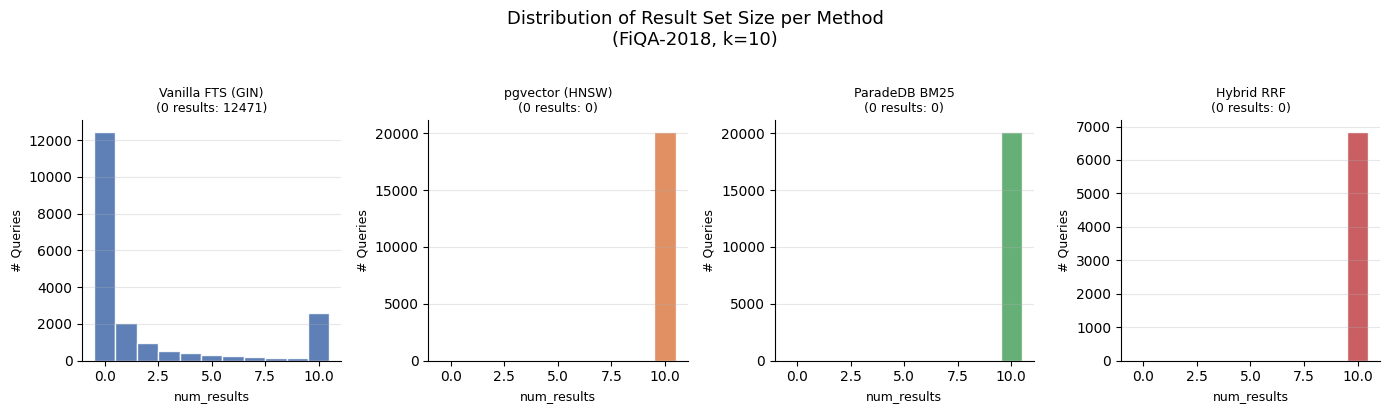

Saved: num_results_hist.png


In [17]:
# ── Histogram of num_results per method ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

for ax, method in zip(axes, METHOD_ORDER):
    data  = bench.loc[bench['method'] == method, 'num_results']
    color = PALETTE[method]

    counts = data.value_counts().sort_index()
    bins   = np.arange(-0.5, data.max() + 1.5, 1) if data.max() > 0 else np.arange(-0.5, 1.5, 1)
    ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.9)

    n_zero = int((data == 0).sum())
    ax.set_title(f'{METHOD_DISPLAY[method]}\n(0 results: {n_zero})', fontsize=9)
    ax.set_xlabel('num_results', fontsize=9)
    ax.set_ylabel('# Queries', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle('Distribution of Result Set Size per Method\n(FiQA-2018, k=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('num_results_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: num_results_hist.png')

In [18]:
# ── Which queries does Vanilla FTS fail on? ────────────────────────────────────
fts_zero = bench[
    (bench['method'] == 'vanilla_fts') & (bench['num_results'] == 0)
][['query_ext_id', 'query_text']].head(10)

print('Sample queries where Vanilla FTS returned 0 results:')
for _, row in fts_zero.iterrows():
    print(f'  [{row.query_ext_id}] {row.query_text[:90]}')

Sample queries where Vanilla FTS returned 0 results:
  [4] Business Expense - Car Insurance Deductible For Accident That Occurred During a Business T
  [12] Does U.S. tax code call for small business owners to count business purchases as personal 
  [13] How can I register a UK business without providing a business address?
  [20] Would the purchase of a car for a business through the use of a business loan be considere
  [21] Deducting last years (undocumented) side business loss
  [28] Tax whilst starting a business in full time employment
  [32] Why is “cheque cashing” a legitimate business?
  [45] How to transfer personal auto lease to business auto lease?
  [46] Tutoring Business Payroll Management
  [49] Why can't online transactions be completed outside of business hours?


**Observations:**
- **Vanilla FTS (GIN)** frequently returns 0 results for FiQA queries because FiQA queries are conversational and use common vocabulary that PostgreSQL's `ts_rank`/`tsvector` stop-word removal may suppress. Many financial terms are multi-word phrases not indexed as single tokens.
- **pgvector** and **Hybrid RRF** always return exactly k=10 results (HNSW is an approximate nearest-neighbor search with guaranteed k results).
- **ParadeDB BM25** may occasionally return fewer than k results when no document achieves a positive BM25 score, but this is rare.

Zero-result queries directly depress recall and NDCG for Vanilla FTS — this is a primary driver of its near-zero retrieval quality score.

---
## Summary

| Method | NDCG@10 | Median P50 Latency | Index Size | Build Time |
|--------|---------|-------------------|-----------|------------|
| Vanilla FTS (GIN) | 0.047 | ~0.8 ms | 18.7 MB | 1.07 s |
| pgvector (HNSW)   | **0.367** | ~1.9 ms | 112 MB | 18.8 s |
| ParadeDB BM25     | 0.233 | ~5.1 ms | 37.7 MB | 0.70 s |
| Hybrid RRF        | 0.360 | ~24.6 ms | (reuses BM25+HNSW) | — |

**Takeaways:**
1. For **semantic corpora** (FiQA), dense vector retrieval (pgvector) dominates on quality.
2. **Hybrid RRF** adds negligible quality improvement over pgvector alone on this dataset while paying 13x the latency — pgvector dominates it on both axes.
3. **ParadeDB BM25** achieves roughly 63% of pgvector's NDCG at 2.7x the latency — not competitive on FiQA.
4. **Vanilla FTS** is only suitable as a latency baseline; its retrieval quality on semantic queries is negligible (NDCG=0.047).
5. All latency differences are statistically significant (Wilcoxon p < 0.05), reflecting the distinct computational profiles of GIN lookup vs. HNSW graph traversal.